 Derajat    RMSE train      RMSE val
       1         5.563         4.927
       2          4.93         4.359   <- terbaik (validasi)
       3         4.787         4.575
       4         4.781         4.514
       5         4.773         4.465
       6         4.771         4.567
       7         4.763         10.22
       8         4.633          83.2
       9         4.633         58.11
      10         4.631         82.61
      11          4.63         489.6
      12         4.426      1.94e+04

Derajat terpilih: 2 | RMSE test (dipakai sekali, di akhir): 4.5331


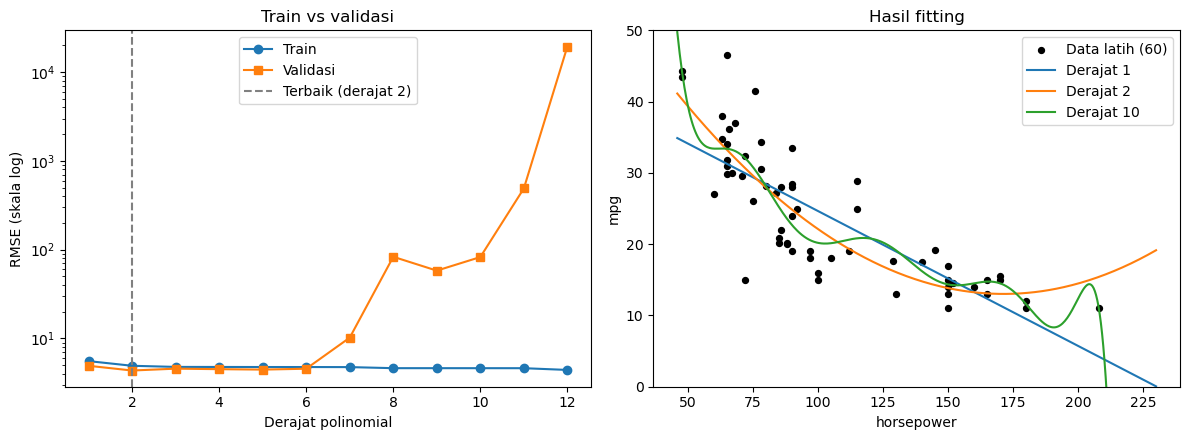


Bagian 3: derajat 2, 313 sampel latih, 3 parameter
cond(X) = 1.08e+01,  cond(X^T X) = 1.17e+02
lr batch GD = 0.454  (batas aman 2/lambda_max = 0.504)

Metode                      RMSE train   RMSE test   Waktu (s)
Normal equation                 4.3823      4.2915      0.0001
sklearn LinearRegression        4.3823      4.2915      0.0009
Batch GD (manual)               4.3823      4.2915      0.0148
SGD (sklearn)                   4.3829      4.2863      0.1404

Koefisien (fitur sudah distandardisasi):
              Normal equatio  sklearn Linear  Batch GD (manu   SGD (sklearn)
intercept            23.5994         23.5994         23.5994         23.6022
x^1                 -18.5172        -18.5172        -18.5172        -18.4678
x^2                  12.5147         12.5147         12.5147         12.5406

Selisih maksimum koefisien dibanding Normal equation:
  Normal equation           0.000000
  sklearn LinearRegression  0.000000
  Batch GD (manual)         0.000000
  SGD (sklearn)  

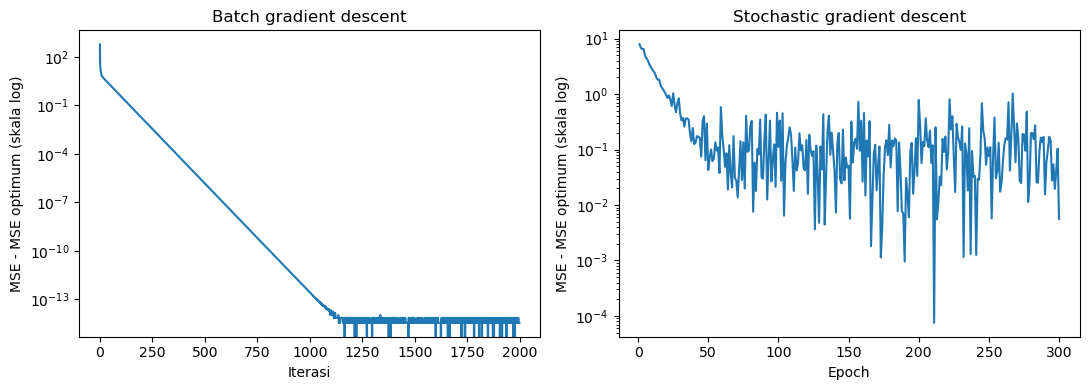

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ============ 1. Data ============
URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(URL).dropna(subset=["horsepower", "mpg"])
x = df[["horsepower"]].values      # fitur tunggal: tenaga mesin
y = df["mpg"].values               # target: konsumsi bahan bakar (mil per galon)

X_rest, X_test, y_rest, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# ============ 2. Memilih derajat: train vs validasi ============
X_train, X_val, y_train, y_val = train_test_split(
    X_rest, y_rest, train_size=60, random_state=42
)

degrees = list(range(1, 13))
train_err, val_err, models = [], [], {}
for d in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=d, include_bias=False),
        StandardScaler(),
        LinearRegression(),
    ).fit(X_train, y_train)
    models[d] = model
    train_err.append(rmse(y_train, model.predict(X_train)))
    val_err.append(rmse(y_val, model.predict(X_val)))

best_d = degrees[int(np.argmin(val_err))]
print(f"{'Derajat':>8s}{'RMSE train':>14s}{'RMSE val':>14s}")
for d, tr, va in zip(degrees, train_err, val_err):
    print(f"{d:8d}{tr:14.4g}{va:14.4g}{'   <- terbaik (validasi)' if d == best_d else ''}")
print(f"\nDerajat terpilih: {best_d} | RMSE test (dipakai sekali, di akhir): "
      f"{rmse(y_test, models[best_d].predict(X_test)):.4f}")

grid = np.linspace(x.min(), x.max(), 400).reshape(-1, 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(degrees, train_err, "o-", label="Train")
ax[0].plot(degrees, val_err, "s-", label="Validasi")
ax[0].axvline(best_d, color="gray", linestyle="--", label=f"Terbaik (derajat {best_d})")
ax[0].set_yscale("log")
ax[0].set_xlabel("Derajat polinomial")
ax[0].set_ylabel("RMSE (skala log)")
ax[0].set_title("Train vs validasi")
ax[0].legend()

ax[1].scatter(X_train, y_train, s=18, color="black", label="Data latih (60)")
for d in sorted({1, best_d, 10}):
    ax[1].plot(grid, models[d].predict(grid), label=f"Derajat {d}")
ax[1].set_ylim(0, 50)
ax[1].set_xlabel("horsepower")
ax[1].set_ylabel("mpg")
ax[1].set_title("Hasil fitting")
ax[1].legend()
plt.tight_layout()
plt.show()

# ============ 3. Closed form vs gradient descent pada fitur polinomial ============
DEGREE = 2
poly = PolynomialFeatures(degree=DEGREE, include_bias=False)
scaler = StandardScaler()
P_train = scaler.fit_transform(poly.fit_transform(X_rest))
P_test = scaler.transform(poly.transform(X_test))

def add_bias(M):
    return np.c_[np.ones(len(M)), M]

Xtr, Xte = add_bias(P_train), add_bias(P_test)
n = len(Xtr)

# Learning rate batch GD
lam_max = np.linalg.eigvalsh((2 / n) * Xtr.T @ Xtr).max()
LR_GD, N_ITER = 0.9 * 2 / lam_max, 2000
ETA0, N_EPOCHS = 0.01, 300          # SGD

print(f"\nBagian 3: derajat {DEGREE}, {n} sampel latih, {Xtr.shape[1]} parameter")
print(f"cond(X) = {np.linalg.cond(Xtr):.2e},  cond(X^T X) = {np.linalg.cond(Xtr.T @ Xtr):.2e}")
print(f"lr batch GD = {LR_GD:.3f}  (batas aman 2/lambda_max = {2 / lam_max:.3f})")

def evaluate(beta, name, seconds):
    return dict(name=name, tr=rmse(y_rest, Xtr @ beta), te=rmse(y_test, Xte @ beta), t=seconds)

results, betas = [], {}

# 3a. Closed form: normal equation
t0 = time.perf_counter()
beta_ne = np.linalg.solve(Xtr.T @ Xtr, Xtr.T @ y_rest)
results.append(evaluate(beta_ne, "Normal equation", time.perf_counter() - t0))
betas["Normal equation"] = beta_ne

# 3b. scikit-learn LinearRegression
t0 = time.perf_counter()
lr_model = LinearRegression().fit(P_train, y_rest)
beta_lr = np.r_[lr_model.intercept_, lr_model.coef_]
results.append(evaluate(beta_lr, "sklearn LinearRegression", time.perf_counter() - t0))
betas["sklearn LinearRegression"] = beta_lr

# 3c. Batch gradient descent
def batch_gd(X, y, lr, n_iter):
    beta = np.zeros(X.shape[1])
    history = []
    with np.errstate(all="ignore"):
        for _ in range(n_iter):
            residual = X @ beta - y
            history.append(np.mean(residual ** 2))
            beta -= lr * (2 / len(y)) * (X.T @ residual)
    return beta, history

t0 = time.perf_counter()
beta_gd, hist_gd = batch_gd(Xtr, y_rest, LR_GD, N_ITER)
results.append(evaluate(beta_gd, "Batch GD (manual)", time.perf_counter() - t0))
betas["Batch GD (manual)"] = beta_gd

# 3d. Stochastic gradient descent (1 partial_fit = 1 epoch)
sgd = SGDRegressor(penalty=None, learning_rate="constant", eta0=ETA0, random_state=42)
rng = np.random.default_rng(42)
hist_sgd = []
t0 = time.perf_counter()
for _ in range(N_EPOCHS):
    idx = rng.permutation(n)
    sgd.partial_fit(P_train[idx], y_rest[idx])
    hist_sgd.append(mean_squared_error(y_rest, sgd.predict(P_train)))
sgd_time = time.perf_counter() - t0
beta_sgd = np.r_[sgd.intercept_, sgd.coef_]
results.append(evaluate(beta_sgd, "SGD (sklearn)", sgd_time))
betas["SGD (sklearn)"] = beta_sgd

print(f"\n{'Metode':26s}{'RMSE train':>12s}{'RMSE test':>12s}{'Waktu (s)':>12s}")
for r in results:
    print(f"{r['name']:26s}{r['tr']:12.4f}{r['te']:12.4f}{r['t']:12.4f}")

print("\nKoefisien (fitur sudah distandardisasi):")
names = ["intercept"] + [f"x^{k}" for k in range(1, DEGREE + 1)]
print(f"{'':12s}" + "".join(f"{k[:14]:>16s}" for k in betas))
for i, nm in enumerate(names):
    print(f"{nm:12s}" + "".join(f"{b[i]:16.4f}" for b in betas.values()))

print("\nSelisih maksimum koefisien dibanding Normal equation:")
for k, b in betas.items():
    print(f"  {k:26s}{np.max(np.abs(b - beta_ne)):.6f}")

# ============ 4. Efek standardisasi pada gradient descent ============
Raw = add_bias(poly.transform(X_rest))                  # fitur polinomial mentah (x, x^2, ...)
_, hist_raw = batch_gd(Raw, y_rest, lr=0.1, n_iter=50)
print(f"\nBatch GD TANPA standardisasi (lr=0.1, 50 iterasi): MSE akhir = {hist_raw[-1]}")
print(f"Batch GD DENGAN standardisasi (lr={LR_GD:.3f}, 50 iterasi): MSE akhir = {hist_gd[49]:.4f}")

# ============ 5. Kurva loss (selisih terhadap MSE optimum normal equation) ============
mse_opt = np.mean((Xtr @ beta_ne - y_rest) ** 2)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(np.array(hist_gd) - mse_opt)
ax[0].set_yscale("log")
ax[0].set_xlabel("Iterasi")
ax[0].set_ylabel("MSE - MSE optimum (skala log)")
ax[0].set_title("Batch gradient descent")

ax[1].plot(range(1, N_EPOCHS + 1), np.array(hist_sgd) - mse_opt)
ax[1].set_yscale("log")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MSE - MSE optimum (skala log)")
ax[1].set_title("Stochastic gradient descent")
plt.tight_layout()
plt.show()